In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
data = pd.read_csv('housing.csv')
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [3]:
data.columns


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [4]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
data.shape

(20640, 10)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
data.duplicated().sum()

0

In [8]:
data['total_bedrooms'].median()

435.0

In [9]:
data.isnull().sum() / len(data) * 100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In [10]:
data["total_bedrooms"] = data["total_bedrooms"].fillna(data["total_bedrooms"].median())

In [11]:
data.select_dtypes('O')

,ocean_proximity
0,NEAR BAY
1,NEAR BAY
2,NEAR BAY
3,NEAR BAY
4,NEAR BAY
...,...
20635,INLAND
20636,INLAND
20637,INLAND
20638,INLAND


In [12]:
data.ocean_proximity.unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [13]:
data = data.drop('ocean_proximity',axis=1)

In [14]:
data.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069120,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066484,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.319026,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.927058,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069120,-0.066484,-0.319026,0.927058,1.000000,0.873535,0.974366,-0.007617,0.049457
population,0.099773,-0.108785,-0.296244,0.857126,0.873535,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.974366,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007617,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049457,-0.024650,0.065843,0.688075,1.000000


In [15]:
X = data.drop('median_house_value',axis=1)
y = data.median_house_value

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
y_pred_train=lr.predict(X_train)

In [20]:
y_pred_train

array([181313.23430336, 286451.78145112, 263328.07605751, ...,
       191338.67423603, 273178.05856515, 278432.75202799])

In [21]:
y_pred_test=lr.predict(X_test)

In [22]:
pd.DataFrame({'Y_TRUE':y_train, 'Y_PRED':y_pred_train})

,Y_TRUE,Y_PRED
14196,103000.0,181313.234303
8267,382100.0,286451.781451
17445,172600.0,263328.076058
14265,93400.0,140991.314024
2271,96500.0,177337.398155
...,...,...
11284,229200.0,313563.976196
11964,97800.0,140968.448111
5390,222100.0,191338.674236
860,283500.0,273178.058565


In [23]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_train, y_pred_train))
print("MSE:", mean_squared_error(y_train, y_pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("R2 Score:", r2_score(y_train, y_pred_train))

MAE: 50626.79448983826
MSE: 4811134397.884198
RMSE: 69362.34135238081
R2 Score: 0.6400947924305292


In [24]:
print("MAE:", mean_absolute_error(y_test, y_pred_test))
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("R2 Score:", r2_score(y_test, y_pred_test))

MAE: 51810.483628042806
MSE: 5059928371.165346
RMSE: 71133.17349286018
R2 Score: 0.6138664756435184


# Feature Engineering

In [25]:
df = pd.read_csv('housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [26]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [27]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [28]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()

In [29]:
encoded = ohe.fit_transform(df[['ocean_proximity']])
encoded_categories = pd.DataFrame(encoded.toarray(),columns = ohe.get_feature_names_out())

In [30]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

In [31]:
dfc = pd.concat([df,encoded_categories],axis=1)

In [32]:
dfc

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,5.045455,0.224625,2.560606,0.0,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,6.114035,0.215208,3.122807,0.0,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,5.205543,0.215173,2.325635,0.0,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,5.329513,0.219892,2.123209,0.0,1.0,0.0,0.0,0.0


In [33]:
dfc = dfc.drop('ocean_proximity',axis=1)

In [34]:
X = dfc.drop('median_house_value',axis=1)
y = dfc.median_house_value

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
y_pred_train=lr.predict(X_train)

In [38]:
y_pred_train

array([181746.54359616, 290558.74973503, 244957.50017772, ...,
       197051.2995346 , 279786.48017603, 274169.26111074])

In [39]:
y_pred_test=lr.predict(X_test)

In [41]:
print("MAE:", mean_absolute_error(y_train, y_pred_train))
print("MSE:", mean_squared_error(y_train, y_pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("R2 Score:", r2_score(y_train, y_pred_train))

MAE: 48785.16002488473
MSE: 4568841694.426771
RMSE: 67593.20745775252
R2 Score: 0.658219916053923


In [42]:
print("MAE:", mean_absolute_error(y_test, y_pred_test))
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("R2 Score:", r2_score(y_test, y_pred_test))

MAE: 50888.6600157193
MSE: 5280716470.093943
RMSE: 72668.53837868175
R2 Score: 0.5970176824350818


# Outlier Handling

In [43]:
0Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3-Q1

In [46]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q1 + 1.5 * IQR

In [47]:
non_outlier_mask = (y_train >= lower_bound ) & (y_train <= upper_bound) 

In [48]:
X_train_clean = X_train[non_outlier_mask]
y_train_clean = y_train[non_outlier_mask]

In [53]:
print(f"purana Train Size:{len(y_train)},outlier hatane ke baad size:{len(y_train_clean)}")

purana Train Size:16512,outlier hatane ke baad size:14155


In [55]:
y_train_log = np.log1p(y_train_clean)

In [56]:
lr = LinearRegression()
lr.fit(X_train_clean,y_train_log)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
y_train_pred_log = lr.predict(X_train_clean)
y_train_pred =np.expm1(y_train_pred_log) 

In [59]:
y_test_pred_log = lr.predict(X_test)
y_test_pred =np.expm1(y_test_pred_log)

In [62]:
print("MAE:", mean_absolute_error(y_train_clean, y_train_pred))
print("MSE:", mean_squared_error(y_train_clean, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train_clean, y_train_pred)))
print("R2 Score:", r2_score(y_train_clean, y_train_pred))

MAE: 34766.72637677615
MSE: 2448104447.7568083
RMSE: 49478.32300873594
R2 Score: 0.5364340744033982


In [63]:
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2 Score:", r2_score(y_test, y_test_pred))

MAE: 57793.54888592916
MSE: 25151110032.8775
RMSE: 158591.01498154775
R2 Score: -0.9193328533692195


# Standard Scaling

In [64]:
from sklearn.preprocessing import StandardScaler

In [65]:
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [66]:
y_train_capped = y_train.clip(lower= lower_bound , upper=upper_bound)

In [67]:
scaler = StandardScaler()

In [77]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

In [78]:
lr = LinearRegression()
lr.fit(X_train_scaled,y_train_capped)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [79]:
y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

In [80]:
print("MAE:", mean_absolute_error(y_train_capped , y_train_pred ))
print("MSE:", mean_squared_error(y_train_capped , y_train_pred ))
print("RMSE:", np.sqrt(mean_squared_error(y_train_capped , y_train_pred )))
print("R2 Score:", r2_score(y_train_capped ,y_train_pred ))

MAE: 48180.557244932825
MSE: 4405350835.541831
RMSE: 66372.81699266523
R2 Score: 0.6579946566680157


In [81]:
print("MAE:", mean_absolute_error(y_test, y_test_pred ))
print("MSE:", mean_squared_error(y_test, y_test_pred ))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_test_pred )))
print("R2 Score:", r2_score(y_test,y_test_pred))

MAE: 50701.57086777486
MSE: 5225364640.0362425
RMSE: 72286.68369787234
R2 Score: 0.60124169424947


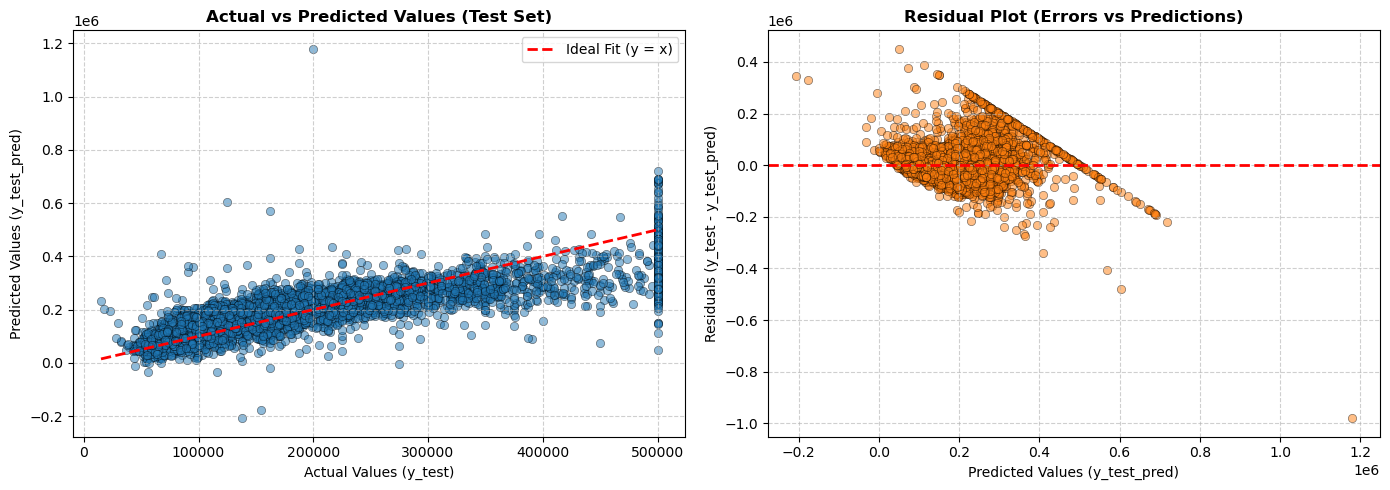

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------------------------------------------
# PLOT 1: Actual vs Predicted Values
# -------------------------------------------------------------
axes[0].scatter(y_test, y_test_pred, alpha=0.5, color='#1f77b4', edgecolors='k', linewidth=0.5)
# Red reference line (Perfect Prediction Line y = x)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit (y = x)')
axes[0].set_title('Actual vs Predicted Values (Test Set)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Values (y_test)', fontsize=10)
axes[0].set_ylabel('Predicted Values (y_test_pred)', fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)


# -------------------------------------------------------------
# PLOT 2: Residual Plot (Prediction Errors)
# -------------------------------------------------------------
residuals = y_test - y_test_pred

axes[1].scatter(y_test_pred, residuals, alpha=0.5, color='#ff7f0e', edgecolors='k', linewidth=0.5)
# Zero error reference line
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_title('Residual Plot (Errors vs Predictions)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Values (y_test_pred)', fontsize=10)
axes[1].set_ylabel('Residuals (y_test - y_test_pred)', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

is pore model description bna ker do roman urdu me jis me ye bataye gaya ho ke humne data clean kia phir normal data ko model me feed kia phir uske metrics ko analyze kia us model ko improve kerne ke llia multiple features apply kia jiase onehotencoding , feateure engineering , outlier handlling , caping , or phir standard scaling apni ter kosish ke ke bad model humare khyal me apne max improvment tk pohanch gya phir humne usko visualize ker ke bhi dekhya .....ek acha sa isko roman urdu me hi or english m bhi liko jo professional lage//
